In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import torch
print("GPU:", torch.cuda.is_available())

GPU: True


In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

# Directive
data_dir = '/content/caltech101/caltech-101'
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
targets = full_dataset.targets

# Stratified Split (70:15:15)
train_idx, temp_idx = train_test_split(
    range(len(targets)), test_size=0.3, stratify=targets, random_state=42
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[targets[i] for i in temp_idx], random_state=42
)

# Dataloader
train_loader = DataLoader(Subset(full_dataset, train_idx), batch_size=32, shuffle=True)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=32)
test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=32)

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

Train: 6400, Val: 1372, Test: 1372


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero

              precision    recall  f1-score   support

           0       0.23      0.34      0.27        70
           1       0.80      1.00      0.89        66
           2       0.93      1.00      0.96        66
           3       0.55      0.97      0.70        30
           4       0.99      1.00      1.00       120
           5       1.00      0.88      0.93         8
           6       0.91      0.96      0.93       120
           7       0.50      0.33      0.40         6
           8       0.00      0.00      0.00         6
           9       0.29      0.29      0.29         7
          10       1.00      0.25      0.40         8
          11       0.00      0.00      0.00         7
          12       1.00      0.20      0.33         5
          13       0.35      0.47      0.40        19
          14       0.47      0.53      0.50        15
          15       0.33      0.29      0.31         7
          16       0.80      0.62      0.70        13
          17       0.47    

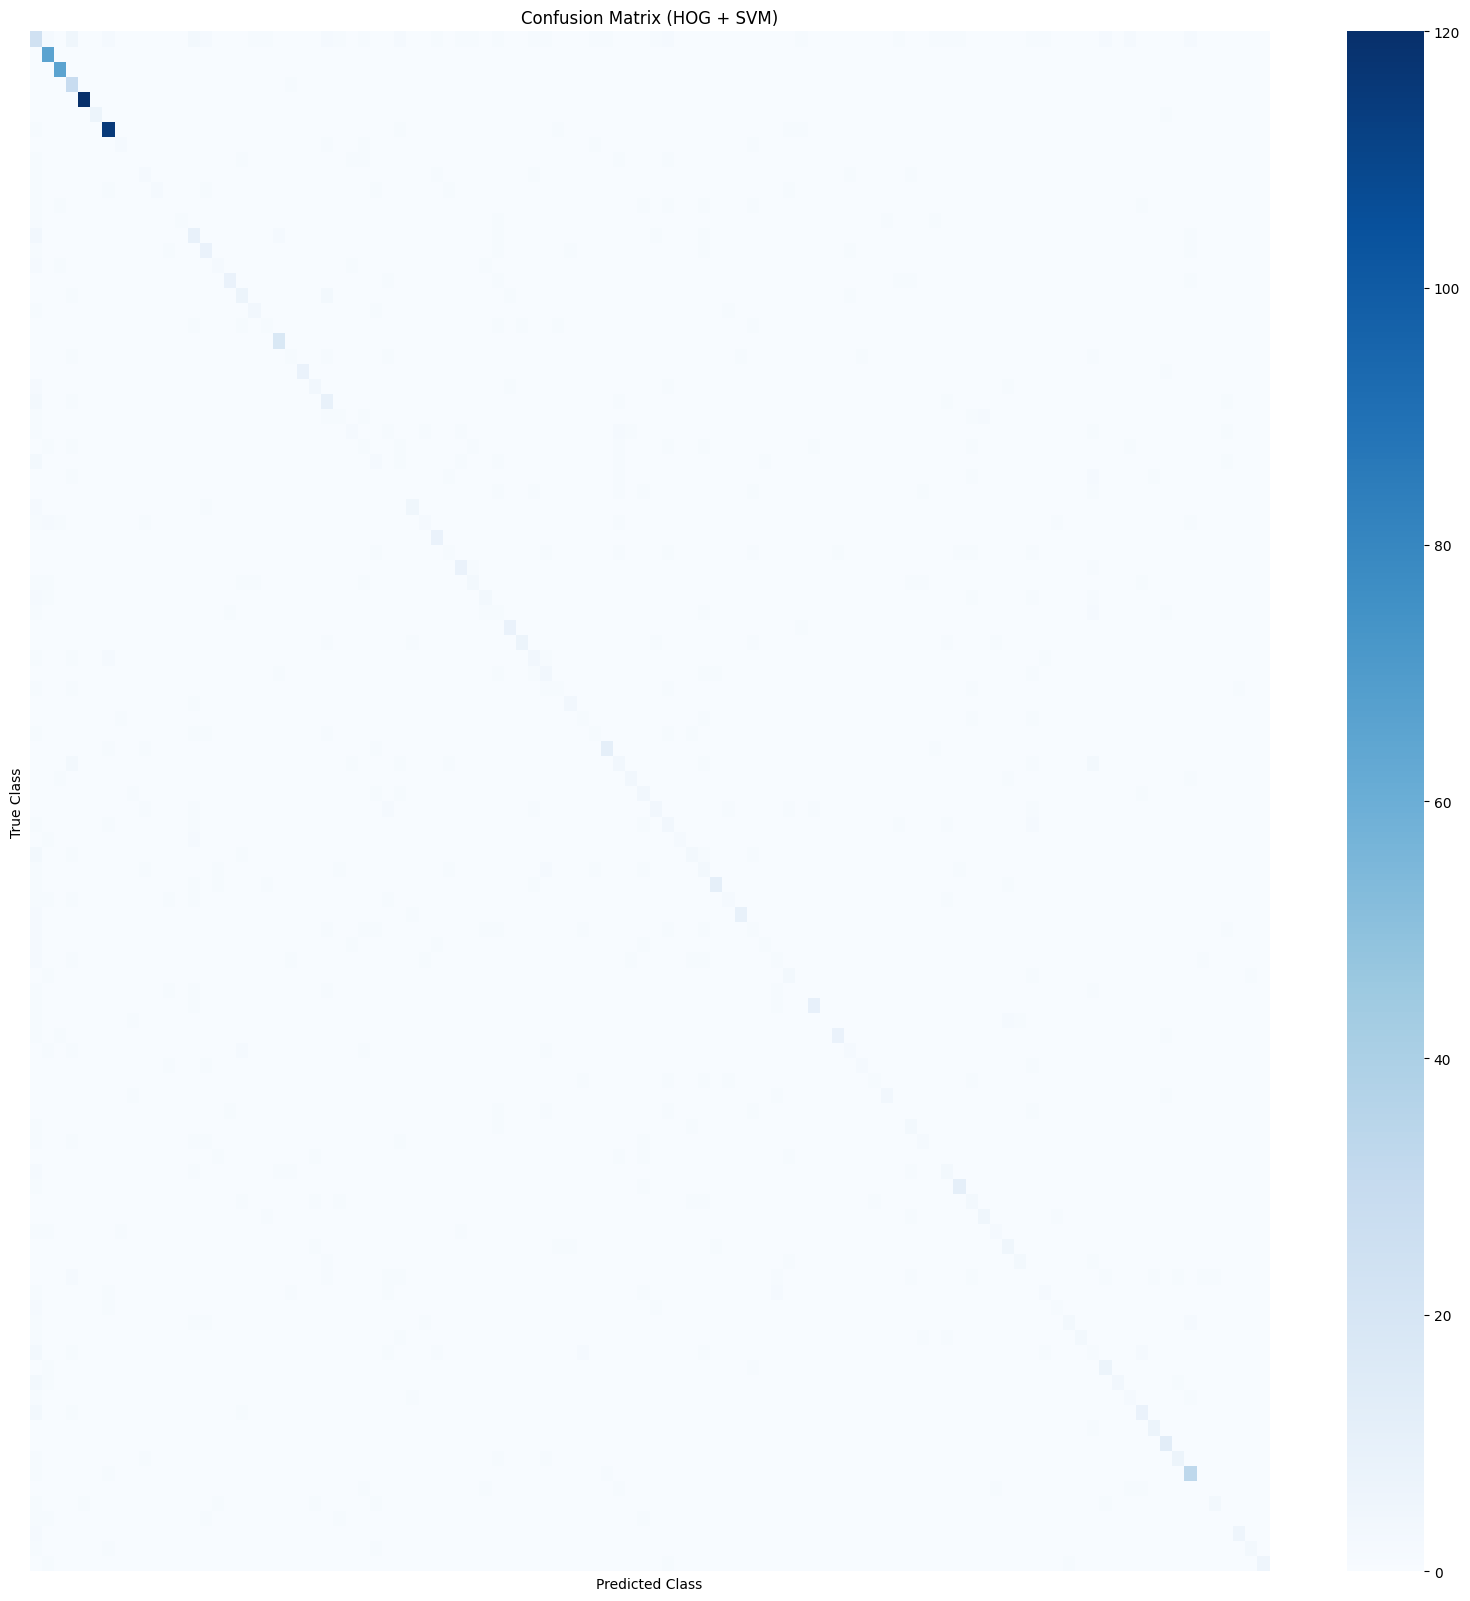

Top-5 Accuracy: 0.7434


In [14]:
import numpy as np
from skimage.feature import hog
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def extract_hog_features(loader):
    features = []
    labels = []
    for imgs, lbls in loader:
        for img in imgs:
            # RGB -> Grayscale
            gray_img = img.mean(axis=0)
            fd = hog(gray_img.numpy(), orientations=9, pixels_per_cell=(8, 8),
                     cells_per_block=(2, 2), visualize=False)
            features.append(fd)
        labels.extend(lbls.numpy())
    return np.array(features), np.array(labels)

#(Train/Test)
X_train, y_train = extract_hog_features(train_loader)
X_test, y_test = extract_hog_features(test_loader)

# SVM 
svm_model = LinearSVC(random_state=42)
svm_model.fit(X_train, y_train)

# evaluation
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, cmap='Blues', xticklabels=False, yticklabels=False)
plt.title('Confusion Matrix (HOG + SVM)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# 2. Top-5 Accuracy
decision_scores = svm_model.decision_function(X_test)
top5_preds = np.argsort(decision_scores, axis=1)[:, -5:]
top5_correct = 0
for i in range(len(y_test)):
    if y_test[i] in top5_preds[i]:
        top5_correct += 1

top5_accuracy = top5_correct / len(y_test)
print(f"Top-5 Accuracy: {top5_accuracy:.4f}")